<a href="https://colab.research.google.com/github/jnolorbe/hydrology-peru/blob/main/notebooks/01_data_preprocessing_and_curation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01. Data Preprocessing and Curation
## Project: Spatio-temporal Analysis of Hydrological Response in Peru (2002-2025)

**Author:** Prof. Juan Mendoza-Nolorbe  

**Affiliations:** UNMSM | UNAC

**Phase 1:** Raw Data Acquisition, Spatial Masking, and Temporal Gap-filling.

---
### Overview
This notebook covers the initial pipeline for processing **GRACE/GRACE-FO** datasets.
The workflow includes:
1. **Raw Data Loading:** Importing Mascon NetCDF files.
2. **Spatial Clipping:** Masking the global grid to the Peruvian mainland.
3. **Data Imputation:** Addressing the gap between GRACE and GRACE-FO using statistical interpolation.
4. **Resampling:** Aligning all datasets to a consistent monthly time-step.

# I. Introduction and Metadata

## 1.1. About the Dataset



**Technical specifications of GRACE/GRACE-FO JPL Mascons**

- Version:	RL06.3Mv04
- Processing: Level	3
- Start/Stop Date:	2002-Apr-04 to Present
- Short Name: TELLUS_GRAC-GRFO_MASCON_CRI_GRID_RL06.3_V4

- Description

> This dataset contains gridded monthly global water storage/height anomalies relative to a time-mean, derived from GRACE and GRACE-FO and processed at JPL using the Mascon approach (RL06.3Mv04). A Coastal Resolution Improvement (CRI) filter has been applied to this data set to reduce signal leakage errors across coastlines. For most land hydrology, oceanographic as well as land-ice applications this is the recommend data set for the analysis of surface mass changes. The data are provided in a single data file in netCDF format, with water storage/height anomalies in equivalent water thickness units (cm). The data are derived from solving for monthly gravity field variations on geolocated spherical cap mass concentration functions, rather than global spherical harmonic coefficients. Additionally, realistic geophysical information is introduced during the computation to intrinsically remove correlated errors. Thus, these Mascon grids do not need to be de-correlated or smoothed, like traditional spherical harmonic gravity solutions.

> The complete Mascon solution consists of 4,551 independent estimates of surface mass change that have been derived using an equal-area 3-degree grid of individual mascons. A subset of these individual mascons span coastlines, and contain mixed land and ocean mass change signals. In a post-processing step, the CRI filter is applied to those mixed land/ocean Mascons to separate land and ocean mass. The land mask used to perform this separation is provided in the same directory as this dataset, as are uncertainty values, and the gridded mascon-ID number to enable further analysis. Since the individual mascons act as an inherent smoother on the gravity field, a set of optional gain factors (or scale factors) is provided within the netCDF and can be applied to the solution to study mass change signals at sub-mascon resolution (e.g. for continental hydrology applications). For use-case examples and further background on the gain factors, please see Wiese, Landerer & Watkins, 2016, https://doi.org/10.1002/2016WR019344.

> This RL06.3Mv04 is an updated version of the previous Tellus JPL Mascon RL06.1Mv03 (DOI, 10.5067/TEMSC-3JC63). For a detailed description on the Mascon solution, including the mathematical derivation, implementation of geophysical constraints, and solution validation, please see Watkins et al., 2015, doi: 10.1002/2014JB011547. For a detailed description of the CRI filter implementation, please see Wiese et al., 2016, doi:10.1002/2016WR019344.

- DOI:	10.5067/TEMSC-3JC634

- More information:

https://podaac.jpl.nasa.gov/dataset/TELLUS_GRAC-GRFO_MASCON_CRI_GRID_RL06.3_V4


## 1.2. Data Acquisition and Access Requirements:



**Instructions for Earthdata Login and manual retrieval**

The primary dataset used in this phase is the JPL GRACE/GRACE-FO RL06.3M Mascon (v0.4). Due to NASA's security policies, users must have an Earthdata account to retrieve the NetCDF file.

Instructions for Replication:

1. Log in to NASA Earthdata Search.

2. Download the granule: GRCTellus.JPL.200204_202511.GLO.RL06.3M.MSCNv04CRI.nc

3. Upload the file to the /content/ directory if using Google Colab, or place it in your local data/raw/ folder.

> **Note:** For bulk downloads or cloud-native processing, we recommend using the podaac-data-subscriber tool or direct S3 access in the us-west-2 region.

## 1.3. Technical Rationale for Seasonal Imputation:



**Scientific justification for the hierarchical interpolation approach**

A critical challenge in the GRACE time series is the 11-month gap between the GRACE and GRACE-FO missions (July 2017 – May 2018), along with sporadic missing months.To address this without introducing artificial bias, this notebook implements a Hierarchical Seasonal Imputation strategy:

1. **Outlier-Resistant Filtering.** Before interpolation, we apply a mask based on the Interquartile Range (IQR). By isolating outliers first, we ensure that extreme localized events (which might be noise or unique geophysical spikes) do not distort the "shape" of the fitted curves during the gap-filling process.

2. **Hierarchical Fitting (Quadratic vs. Linear).** The imputation is performed month-by-month in the time domain:

- Quadratic Fit ($ax^2 + bx + c$): Used as the primary method to capture the non-linear, parabolic nature of hydrological recharge and discharge cycles. It better represents the acceleration or deceleration of water storage changes.

- Linear Fit ($mx + b$): Applied as a fallback when the available data points for a specific window are insufficient to constrain a quadratic curve, ensuring mathematical stability.

3. **Seasonal Median Refinement.** For any remaining $NaN$ values that cannot be resolved via regression (e.g., at the very beginning or end of the series), we use the Seasonal Median. This preserves the long-term climatology of the specific month (e.g., "typical March storage") rather than a simple global average, maintaining the physical consistency of the Peruvian hydrological regime.

# II. Environment Setup and Data Loading

## 2.1. Library Import


In [2]:
# Installing libraries for NetCDF
!pip install netCDF4 xarray rioxarray geopandas shapely openpyxl

# Loading xarray, rioxarray, geopandas, and numerical libraries
import xarray as xr
import rioxarray
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 66.7 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [3]:
# Setting Figure Parameters

# Setting parameters for high-quality figure rendering
import matplotlib as mpl

# === 1. FONT EMBEDDING AND FAMILY ===
# Force TrueType fonts (Type 42) to ensure proper embedding in PDF
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# Set default font family to Sans-Serif
plt.rcParams['font.family'] = 'sans-serif'
# Try using Arial or Helvetica; if unavailable, fall back to Colab's default (DejaVu Sans)
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans', 'Liberation Sans']

# === 2. LEGIBLE FONT SIZES ===
# Ensures text remains readable even when figures are scaled down
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9

# === 3. LINE THICKNESS (Guideline: High-quality line graphics) ===
plt.rcParams['lines.linewidth'] = 1.0  # Líneas claras
plt.rcParams['axes.linewidth'] = 1.0   # Bordes del gráfico claros

## 2.2 Repository Synchronization

In [4]:
import os

# Define repository metadata
REPO_NAME = "hydrology-peru"
GITHUB_USERNAME = "jnolorbe" # Change this if you fork the repo
REPO_URL = f"https://github.com/{GITHUB_USERNAME}/{REPO_NAME}.git"

# Clone the repository to access the 45MB raw data and shapefiles
if not os.path.exists(REPO_NAME):
    print("Status: Cloning repository from GitHub...")
    !git clone {REPO_URL}
else:
    print("Status: Repository already exists. Pulling latest updates...")
    %cd {REPO_NAME}
    !git pull
    %cd ..


Status: Cloning repository from GitHub...
Cloning into 'hydrology-peru'...
remote: Enumerating objects: 95, done.
remote: Counting objects: 100% (95/95), done.
remote: Compressing objects: 100% (80/80), done.
remote: Total 95 (delta 18), reused 6 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (95/95), 49.84 MiB | 16.25 MiB/s, done.
Resolving deltas: 100% (18/18), done.


## 2.3 Data Loading

In [5]:
# Define relative paths to the cloned repository structure
raw_data_path = f"{REPO_NAME}/data/raw/GRCTellus.JPL.200204_202511.GLO.RL06.3M.MSCNv04CRI.nc"
shape_path = f"{REPO_NAME}/data/shapefiles/departamentos_peru/country_shapes.shp"

# Load the global GRACE/GRACE-FO dataset
try:
    ds_raw = xr.open_dataset(raw_data_path)
    print(f"Success: Global dataset loaded. Time steps: {len(ds_raw.time)}")
except FileNotFoundError:
    print("Error: NetCDF file not found. Check the data/raw/ directory.")

# Load Peru's national boundaries as a GeoDataFrame
peru_shp = gpd.read_file(shape_path)
print("Success: National shapefile loaded.")

Success: Global dataset loaded. Time steps: 251
Success: National shapefile loaded.


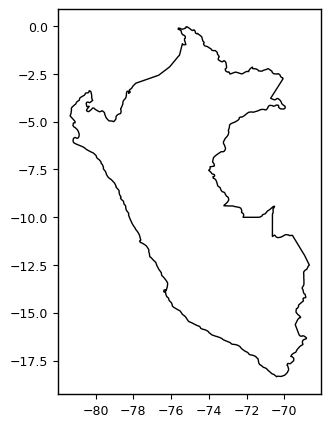

In [6]:
# Visualizing the loaded shapefile to ensure geometry integrity
fig, ax = plt.subplots(figsize=(10,5))
peru_shp.geometry.plot(edgecolor = "black", color = "None", ax=ax, lw=1.0)
plt.show()
plt.close()

# III. Spatial Domain Definition (Clipping)

## 3.1 Spatial Subsetting

In [7]:
# Define the geographical boundaries for the Peruvian study area
lat_min, lat_max = -18.25, -0.25
lon_min, lon_max = -81.25, -68.25

# NASA JPL Mascons utilize a 0-360 longitude convention.
# Coordinate adjustment for the Western Hemisphere:
lon_min_adj = 360 + lon_min  # -81.25 -> 278.75
lon_max_adj = 360 + lon_max  # -68.25 -> 291.75

# Execute the spatial slice (rectangular bounding box)
# We keep the object in memory (ds_peru_box) for the curation phase.
ds_peru_box = ds_raw.sel(
    lat=slice(lat_min, lat_max),
    lon=slice(lon_min_adj, lon_max_adj)
)

ds_peru_box = ds_peru_box.assign_coords(lon=(((ds_peru_box.lon + 180) % 360) - 180))

# Sort longitude to ensure they are in increasing order after conversion
ds_peru_box = ds_peru_box.sortby('lon')

print(f"Status: Spatial subset successfully created.")
#print(f"New Domain Dimensions: {dict(ds_peru_box.dims)}")
print(f"New Domain Dimensions (Sizes): {dict(ds_peru_box.sizes)}")
print(f"Time Range: {ds_peru_box.time.values[0]} to {ds_peru_box.time.values[-1]}")


Status: Spatial subset successfully created.
New Domain Dimensions (Sizes): {'time': 251, 'lat': 37, 'lon': 27, 'bounds': 2}
Time Range: 2002-04-17T12:00:00.000000000 to 2025-11-16T00:00:00.000000000


## 3.2 Preliminary Inspection

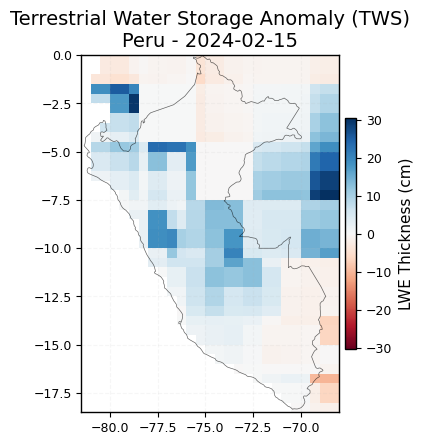

In [9]:
## Spatial Verification

# 1. Target date selection (Example: February 2024)
target_date = '2024-02-15'
#tws_map = ds_peru_box['lwe_thickness'].sel(time=target_date, method='nearest')
tws_raw = ds_peru_box['lwe_thickness'].sel(time=target_date, method='nearest')
tws_map = tws_raw * ds_peru_box['scale_factor']
# 2. Map Visualization
fig, ax = plt.subplots(figsize=(4, 5))

# Plotting GRACE data using 'RdBu' (Red for drought, Blue for wetness)
# Note: 'center=0' ensures that white represents zero anomaly
im = tws_map.plot(ax=ax, cmap='RdBu', center=0, add_colorbar=False)

# 3. Overlaying the ANA Shapefile (Basin boundaries)
# Using the shapefile loaded in previous sections
peru_shp.boundary.plot(ax=ax, color='black', linewidth=0.5, alpha=0.6)

# 4. Map Customization
plt.title(f"Terrestrial Water Storage Anomaly (TWS)\nPeru - {str(tws_map.time.values)[:10]}", fontsize=14)
plt.xlabel("")
plt.ylabel("")

# Customizing the Colorbar
cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02, shrink=0.6)
cbar.set_label('LWE Thickness (cm)', fontsize=11)

plt.grid(True, linestyle='--', alpha=0.1)
plt.show()
plt.close(fig)

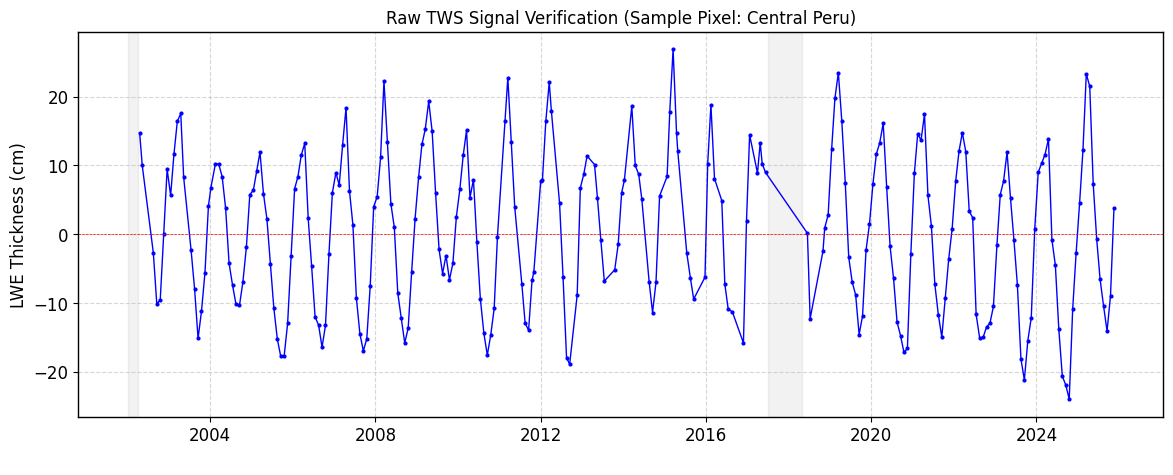

In [11]:
## Temporal Verification

# 1. Coordinate Selection (Standardized -180/180)
# Representative pixel in the Amazon/Ucayali region
pixel_lat, pixel_lon = -10.25, -74.75

# 2. Extracting and Scaling the Time Series
# Selecting the nearest pixel and applying the physical scale factor
ts_raw = ds_peru_box['lwe_thickness'].sel(lat=pixel_lat, lon=pixel_lon, method='nearest')
scale_factor_at_point = ds_peru_box['scale_factor'].sel(lat=pixel_lat, lon=pixel_lon, method='nearest')

ts_scaled = ts_raw * scale_factor_at_point

# 3. Visualization
plt.figure(figsize=(14, 5))

# Plotting with markers to clearly identify individual data points and gaps
ts_scaled.plot(marker='o', markersize=2, linestyle='-', linewidth=1,label='Scaled TWS (cm)',  color='blue')

# Highlighting the standardized start (2002-01 to 2002-03 will be empty)
plt.axvspan('2002-01-01', '2002-04-01', color='gray', alpha=0.1, label='Pre-mission Period (NaNs)')
plt.axvspan('2017-07-01', '2018-05-01', color='gray', alpha=0.1, label='Gap GRACE / GRACE FO Period (NaNs)')

# 4. Customization and Context
plt.title(f"Raw TWS Signal Verification (Sample Pixel: {pixel_lat} Lat, {pixel_lon} Lon)", fontsize=13)
plt.title("Raw TWS Signal Verification (Sample Pixel: Central Peru)", fontsize=12)
plt.ylabel("LWE Thickness (cm)", fontsize=12)
plt.xlabel(" ")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.axhline(0, color='red', linestyle='--', linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.5)

# Highlighting the GRACE/GRACE-FO Mission Gap (2017-2018)
plt.show()
plt.close()



Descriptive Statistics for TWS (Scaled, in cm LWE):
--------------------------------------------------
Minimum:              -71.73 cm
Maximum:              100.22 cm
Mean:                   0.73 cm
Median (Q2):            0.30 cm
Standard Deviation:    12.29 cm
First Quartile (Q1):   -4.42 cm
Third Quartile (Q3):    6.00 cm
Interquartile Range:   10.42 cm
--------------------------------------------------


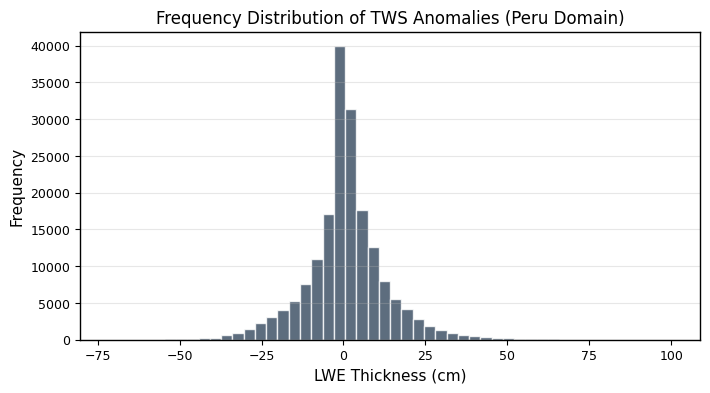

In [12]:
# Domain-Wide Descriptive Statistics

# 1. Access the variables from the spatial subset (ds_peru_box)
# Applying the scale factor to the entire 3D array (Time, Lat, Lon)
lwe_scaled = ds_peru_box['lwe_thickness'] * ds_peru_box['scale_factor']

# 2. Compute main statistical metrics
# Using .item() to extract the scalar value from the xarray object
min_val    = lwe_scaled.min().item()
max_val    = lwe_scaled.max().item()
mean_val   = lwe_scaled.mean().item()
median_val = lwe_scaled.median().item()
std_dev    = lwe_scaled.std().item()
q25        = lwe_scaled.quantile(0.25).item()
q75        = lwe_scaled.quantile(0.75).item()
iqr        = q75 - q25  # Interquartile Range

# 3. Print the statistical summary for the Peruvian domain
print(f"\nDescriptive Statistics for TWS (Scaled, in cm LWE):")
print("-" * 50)
print(f"Minimum:            {min_val:8.2f} cm")
print(f"Maximum:            {max_val:8.2f} cm")
print(f"Mean:               {mean_val:8.2f} cm")
print(f"Median (Q2):        {median_val:8.2f} cm")
print(f"Standard Deviation: {std_dev:8.2f} cm")
print(f"First Quartile (Q1):{q25:8.2f} cm")
print(f"Third Quartile (Q3):{q75:8.2f} cm")
print(f"Interquartile Range:{iqr:8.2f} cm")
print("-" * 50)

# Optional: Histogram to visualize the data distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
lwe_scaled.plot.hist(bins=50, color='#34495e', edgecolor='white', alpha=0.8)
plt.title("Frequency Distribution of TWS Anomalies (Peru Domain)", fontsize=12)
plt.xlabel("LWE Thickness (cm)")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.show()
plt.close()

# IV. Hierarchical Seasonal Imputation

## 4.1 Data Scaling and Temporal resampling

In [13]:
# 1. Apply physical scaling to the entire dataset
ds_peru_box['lwe_thickness_corrected'] = ds_peru_box['lwe_thickness'] * ds_peru_box['scale_factor']

# 2. Define the standardized monthly time index
start_date = pd.to_datetime('2002-01-01')
end_date = pd.to_datetime('2025-12-01')
new_time_index = pd.date_range(start=start_date, end=end_date, freq='MS')

# 3. Resample to Monthly Start (MS) and Reindex
# We use .mean() to aggregate if multiple granules exist in a month
ds_peru_resampled = ds_peru_box['lwe_thickness_corrected'].resample(time='MS').mean()
ds_peru_resampled_reindexed = ds_peru_resampled.reindex(time=new_time_index)

print(f"Status: Data resampled and reindexed to {len(new_time_index)} months.")
print(f"Standardized Time Range: {new_time_index[0].date()} to {new_time_index[-1].date()}")

Status: Data resampled and reindexed to 288 months.
Standardized Time Range: 2002-01-01 to 2025-12-01


## 4.2 Outlier Detection and masking

In [14]:
# 1. Calculate IQR-based bounds (using 1.5 multiplier)
Q1 = ds_peru_resampled_reindexed.quantile(0.25)
Q3 = ds_peru_resampled_reindexed.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Identify the outlier mask
outlier_mask = (ds_peru_resampled_reindexed < lower_bound) | (ds_peru_resampled_reindexed > upper_bound)

# 3. Store original outlier values for future restitution
outliers_original = ds_peru_resampled_reindexed.where(outlier_mask).copy()

# 4. Generate a working dataset with outliers replaced by NaNs
ds_peru_clean_nan = ds_peru_resampled_reindexed.where(~outlier_mask)

print(f"Status: Outlier detection complete.")
print(f"IQR: {IQR.item():.2f} | Bounds: [{lower_bound.item():.2f}, {upper_bound.item():.2f}]")
print(f"Total Outliers Detected: {outliers_original.count().item()}")

Status: Outlier detection complete.
IQR: 10.39 | Bounds: [-20.08, 21.50]
Total Outliers Detected: 17965


## 4.3 Hierarchical Interoplation Function

In [15]:
# Define the interpolation function
def safe_interpolate_seasonal(data_array_month):
    """
    Applies quadratic interpolation along the 'time' dimension.
    If it fails due to insufficient data points, it falls back to linear.
    """
    try:
        # Attempt quadratic (parabolic) interpolation for better hydrological fit
        interpolated_data = data_array_month.interpolate_na(dim='time', method='quadratic')
    except (ValueError, Exception):
        # Fallback to linear interpolation if quadratic constraints are not met
        interpolated_data = data_array_month.interpolate_na(dim='time', method='linear')
    return interpolated_data



In [16]:
# Seasonal Imputation and Outliers Restitution
# Applying the interpolation grouped by month (Seasonal Imputation)
ds_interpolated_seasonal = ds_peru_clean_nan.groupby('time.month').apply(safe_interpolate_seasonal)

# Restore original outliers into the interpolated dataset
# We use .combine_first() to prioritize real extreme events over synthetic values
GRACE_Peru_final_IQR1_5 = outliers_original.combine_first(ds_interpolated_seasonal)

print("Status: Seasonal imputation and outlier restitution complete.")
print(f"Final Data Shape: {GRACE_Peru_final_IQR1_5.sizes}")


Status: Seasonal imputation and outlier restitution complete.
Final Data Shape: Frozen({'time': 288, 'lat': 37, 'lon': 27})


In [17]:
# Final Climatology Filling (Median-Based)

# Calculate the seasonal median (climatology) for each month
# This provides a representative value based on the historical monthly behavior
monthly_medians = ds_interpolated_seasonal.groupby('time.month').median(dim='time')

# Fill any remaining NaNs (typically at the start/end of the series)
# We apply the median of the corresponding month to ensure physical consistency
GRACE_Peru_final_IQR1_5 = GRACE_Peru_final_IQR1_5.groupby('time.month').fillna(monthly_medians)

# Final verification of data continuity
remaining_nans = GRACE_Peru_final_IQR1_5.isnull().sum().values
print(f"Status: Final climatological filling complete.")
print(f"Total NaN values remaining in the dataset: {remaining_nans}")

Status: Final climatological filling complete.
Total NaN values remaining in the dataset: 78062


## 4.4 Spatial and Temporal Verification

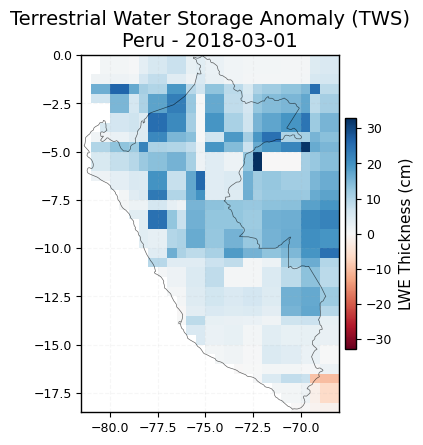

In [18]:
## Spatial Verification

# 1. Target date selection (Example: February 2024)
target_date = '2018-03-01'
tws_map = GRACE_Peru_final_IQR1_5.sel(time=target_date, method='nearest')

# 2. Map Visualization
fig, ax = plt.subplots(figsize=(4, 5))

# Plotting GRACE data using 'RdBu' (Red for drought, Blue for wetness)
# Note: 'center=0' ensures that white represents zero anomaly
im = tws_map.plot(ax=ax, cmap='RdBu', center=0, add_colorbar=False)

# 3. Overlaying the ANA Shapefile (Basin boundaries)
# Using the shapefile loaded in previous sections
peru_shp.boundary.plot(ax=ax, color='black', linewidth=0.5, alpha=0.6)

# 4. Map Customization
plt.title(f"Terrestrial Water Storage Anomaly (TWS)\nPeru - {str(tws_map.time.values)[:10]}", fontsize=14)
plt.xlabel("")
plt.ylabel("")

# Customizing the Colorbar
cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02, shrink=0.6)
cbar.set_label('LWE Thickness (cm)', fontsize=11)

plt.grid(True, linestyle='--', alpha=0.1)
plt.show()
plt.close(fig)

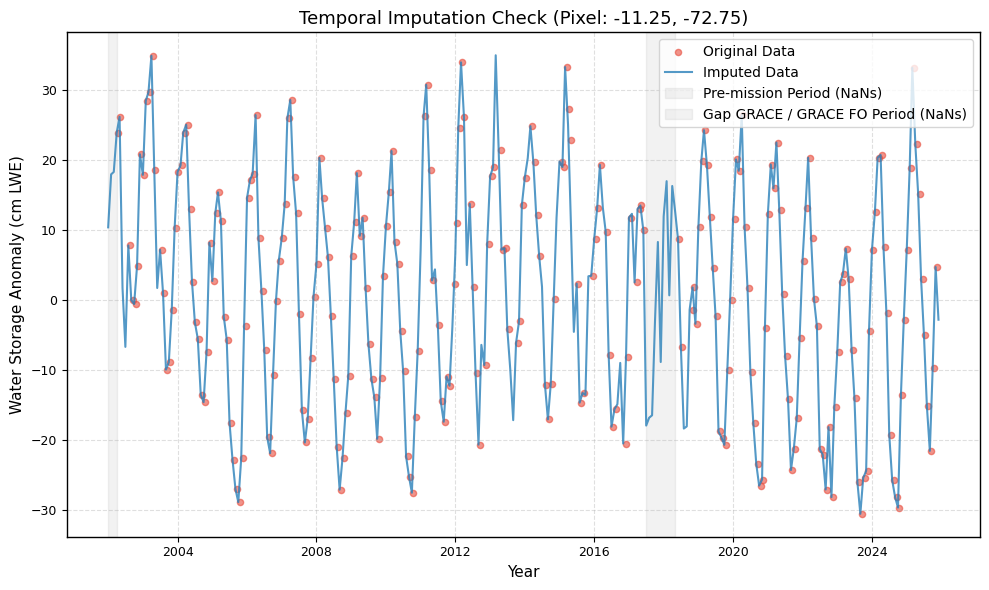

In [19]:
## Temporal Verification

# Selecting the same pixel as before for consistency
pixel_lat, pixel_lon = -11.25, -72.75

# Original data (from the scaled subset)
original_ts = ds_peru_box['lwe_thickness_corrected'].sel(lat=pixel_lat, lon=pixel_lon, method='nearest')

# Reindexed data (resampled and reindexed)
final_ts = GRACE_Peru_final_IQR1_5.sel(lat=pixel_lat, lon=pixel_lon, method='nearest')

plt.figure(figsize=(10,6))

# Plotting original data (dots)
plt.scatter(original_ts.time, original_ts.values, color='#e74c3c', s=20, label='Original Data', alpha=0.6)

# Plotting resampled data (line)
plt.plot(final_ts.time, final_ts.values, color='#2980b9', lw=1.5, label='Imputed Data', alpha=0.8)

plt.title(f"Temporal Imputation Check (Pixel: {pixel_lat}, {pixel_lon})", fontsize=13)
plt.ylabel("Water Storage Anomaly (cm LWE)")
plt.xlabel("Year")
plt.grid(True, which='both', linestyle='--', alpha=0.4)

# Highlighting the standardized start (2002-01 to 2002-03 will be empty)
plt.axvspan('2002-01-01', '2002-04-01', color='gray', alpha=0.1, label='Pre-mission Period (NaNs)')
plt.axvspan('2017-07-01', '2018-05-01', color='gray', alpha=0.1, label='Gap GRACE / GRACE FO Period (NaNs)')

plt.legend()
plt.tight_layout()
plt.show()

plt.close()

In [21]:
## Statistical Comparison Report
# 1. Compute statistics for the Scaled Original Series (Pre-imputation)
# Using the scaled variable from the initial subset
mean_orig   = ds_peru_box['lwe_thickness_corrected'].mean().item()
median_orig = ds_peru_box['lwe_thickness_corrected'].median().item()
std_orig    = ds_peru_box['lwe_thickness_corrected'].std().item()
min_orig    = ds_peru_box['lwe_thickness_corrected'].min().item()
max_orig    = ds_peru_box['lwe_thickness_corrected'].max().item()
count_orig  = ds_peru_box['lwe_thickness_corrected'].count().item()

# 2. Compute statistics for the Final Curated Series (Post-imputation & IQR 1.5)
# Using your final gap-filled and land-masked dataset
mean_final   = GRACE_Peru_final_IQR1_5.mean().item()
median_final = GRACE_Peru_final_IQR1_5.median().item()
std_final    = GRACE_Peru_final_IQR1_5.std().item()
min_final    = GRACE_Peru_final_IQR1_5.min().item()
max_final    = GRACE_Peru_final_IQR1_5.max().item()
count_final  = GRACE_Peru_final_IQR1_5.count().item()

# 3. Print the Comparative Statistical Report
print("\n--- Comparative Report: Descriptive Statistics Verification ---")
print(f"{'Statistic':<25} {'Original Series':<20} {'Final Curated Series':<20}")
print(f"{'-' * 25:<25} {'-' * 20:<20} {'-' * 20:<20}")
print(f"{'Mean:':<25} {mean_orig:<20.4f} {mean_final:<20.4f}")
print(f"{'Median:':<25} {median_orig:<20.4f} {median_final:<20.4f}")
print(f"{'Standard Deviation:':<25} {std_orig:<20.4f} {std_final:<20.4f}")
print(f"{'Minimum:':<25} {min_orig:<20.4f} {min_final:<20.4f}")
print(f"{'Maximum:':<25} {max_orig:<20.4f} {max_final:<20.4f}")
print(f"{'Valid Data Count:':<25} {count_orig:<20} {count_final:<20}")
print("-" * 65)

# 4. Final Verification Summary
change_in_mean = ((mean_final - mean_orig) / mean_orig) * 100 if mean_orig != 0 else 0
print(f"Status: Data integrity verified. Data points increased from {count_orig} to {count_final} due to imputation.")


--- Comparative Report: Descriptive Statistics Verification ---
Statistic                 Original Series      Final Curated Series
------------------------- -------------------- --------------------
Mean:                     0.7292               0.6605              
Median:                   0.2997               0.2770              
Standard Deviation:       12.2949              11.8272             
Minimum:                  -71.7320             -71.7320            
Maximum:                  100.2155             100.2155            
Valid Data Count:         182728               209650              
-----------------------------------------------------------------
Status: Data integrity verified. Data points increased from 182728 to 209650 due to imputation.


# V. Exporting the Curated Datatset

## 5.1. Final Data Export for Reproducibility

This section ensures that the curated dataset is saved for subsequent analysis in 02_statistical_analysis.ipynb. By exporting this file, we decouple the heavy pre-processing stage from the statistical modeling phase.

In [ ]:
import os

# Define the final filename used in the research
output_filename = "GRACE_Peru_final_IQR1_5.nc"
output_dir = f"{REPO_NAME}/data/processed/"
full_output_path = os.path.join(output_dir, output_filename)

# Ensure the processed directory exists within the repository
os.makedirs(output_dir, exist_ok=True)

# Export the land-masked and gap-filled dataset to NetCDF
# This file serves as the primary input for the Trend Analysis (Notebook 02)
try:
    # Use 'GRACE_Peru_final_IQR1_5' or the final object you've verified
    GRACE_Peru_final_IQR1_5.to_netcdf(full_output_path)
    print(f"Success: Curated dataset exported to {full_output_path}")
    print("Status: The environment is now ready for Notebook 02.")
except Exception as e:
    print(f"Error during export: {e}")